# 08 — CG Governance Index → Financial Outcomes: Regression Analysis

In [1]:
import warnings; warnings.filterwarnings('ignore')
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from scipy import stats
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
BASE = Path(os.getcwd())
CG_CATS = ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
CTRL    = ['Beta_Market', 'Momentum', 'Log_MarketCap']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
# Helper functions

def q_sort_key(q):
    m = re.match(r'Q(\d)FY(\d+)', str(q))
    return (int(m.group(2)), int(m.group(1))) if m else (9999, 9)


def vdw_score(s):
    """Van der Waerden normal-score transform (cross-sectional)."""
    n = s.notna().sum()
    if n < 2:
        return pd.Series(np.nan, index=s.index)
    r = s.rank(method='average', na_option='keep')
    return r.map(lambda x: norm.ppf(x / (n + 1)) if pd.notna(x) else np.nan)


def winsorize(s, lo=0.01, hi=0.99):
    q_lo, q_hi = s.quantile([lo, hi])
    return s.clip(q_lo, q_hi)


def sig_stars(p):
    if pd.isna(p): return ''
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''


def vif_table(X_df):
    Xc = sm.add_constant(X_df.astype(float), has_constant='add')
    rows = []
    for i, col in enumerate(Xc.columns):
        if col == 'const': continue
        try:
            rows.append({'Variable': col, 'VIF': variance_inflation_factor(Xc.values, i)})
        except Exception:
            rows.append({'Variable': col, 'VIF': np.nan})
    return (pd.DataFrame(rows).sort_values('VIF', ascending=False)
              .reset_index(drop=True))


def run_ols(df, y_col, x_cols, cluster_col='BSE Code', winsor=True):
    """
    OLS with firm-clustered SE (falls back to HC3 if cluster fails).
    Returns (results, diag_dict) or (None, None) when N < 30.
    """
    cols_needed = [y_col] + x_cols + [cluster_col]
    sub = df[[c for c in cols_needed if c in df.columns]].dropna().copy()
    if len(sub) < 30:
        return None, None
    if winsor:
        sub[y_col] = winsorize(sub[y_col])
    Y     = sub[y_col].astype(float)
    X_raw = sub[x_cols].astype(float)
    X     = sm.add_constant(X_raw, has_constant='add')
    base  = sm.OLS(Y, X).fit()
    try:
        _res = base.get_robustcov_results(cov_type='cluster',
                                          groups=sub[cluster_col].values)
    except Exception:
        _res = base.get_robustcov_results('HC3')
    # Guarantee named Series for params / bse / pvalues
    _xnames = list(X.columns)
    class _Res:
        params   = pd.Series(np.asarray(_res.params),  index=_xnames)
        bse      = pd.Series(np.asarray(_res.bse),     index=_xnames)
        pvalues  = pd.Series(np.asarray(_res.pvalues), index=_xnames)
        tvalues  = pd.Series(np.asarray(_res.tvalues), index=_xnames)
        rsquared     = base.rsquared
        rsquared_adj = base.rsquared_adj
        nobs         = base.nobs
    res = _Res()
    resid = base.resid
    jb_stat, jb_p = jarque_bera(resid)[:2]
    try:
        _, bp_p, _, _ = het_breuschpagan(resid, X)
    except Exception:
        bp_p = np.nan
    # VIF on CG + control cols only (not FE dummies)
    non_fe = [c for c in x_cols if not c.startswith('_FE_')]
    diag = {
        'N': int(res.nobs), 'R2': res.rsquared, 'Adj_R2': res.rsquared_adj,
        'JB_p': jb_p, 'BP_p': bp_p, 'DW': durbin_watson(resid),
        'VIF': vif_table(sub[non_fe]) if len(non_fe) > 1 else pd.DataFrame(),
        'resid': resid.values, 'fitted': base.fittedvalues.values,
    }
    return res, diag


def fe_dummies(df, col, prefix):
    """One-hot FE dummies (drop_first=True), columns prefixed with '_FE_'."""
    d = pd.get_dummies(df[col], prefix=f'_FE_{prefix}', drop_first=True)
    return d


def print_reg_table(run_dict, y_vars, cg_labels, title=''):
    """
    Print a regression summary table.
    run_dict: {(y_var, cg_label): (res, diag)}
    """
    W = 20  # column width
    bar = '=' * (14 + W * len(y_vars))
    print(f'\n{bar}')
    if title:
        print(f'  {title}')
        print(bar)
    header = f"{'CG Index':<12}" + ''.join(f"{y:^{W}}" for y in y_vars)
    print(header)
    sub_h  = f"{'':12}" + ''.join(f"{'β (SE)':^{W}}" for _ in y_vars)
    print(sub_h)
    print('-' * len(bar))
    for cg in cg_labels:
        row = f'{cg:<12}'
        for y in y_vars:
            res, diag = run_dict.get((y, cg), (None, None))
            if res is None:
                row += f"{'—':^{W}}"
            else:
                coef = res.params.get(cg, np.nan)
                se   = res.bse.get(cg, np.nan)
                p    = res.pvalues.get(cg, np.nan)
                cell = f'{coef:+.4f}{sig_stars(p)} ({se:.4f})'
                row += f"{cell:^{W}}"
        print(row)
    print('-' * len(bar))
    # Footer: Controls, FE, N, R² from the COMPOSITE model
    for label, key in [('Controls', 'ctrl'), ('FY/Q FE', 'fe'), ('N', 'N'), ('R²', 'R2')]:
        row = f'{label:<12}'
        for y in y_vars:
            _, diag = run_dict.get((y, 'COMPOSITE'), (None, None))
            if key == 'ctrl':
                row += f"{'Yes':^{W}}"
            elif key == 'fe':
                row += f"{'Yes':^{W}}"
            elif key == 'N' and diag:
                row += f"{diag['N']:^{W}}"
            elif key == 'R2' and diag:
                row += f"{diag['R2']:^{W}.4f}"
            else:
                row += f"{'—':^{W}}"
        print(row)
    print('=' * len(bar))
    print('* p<.10  ** p<.05  *** p<.01  | firm-clustered SE | Y winsorised 1%-99%')


def print_joint_table(joint_dict, y_vars, cg_cols, title=''):
    """Print joint model results (all CG indices simultaneously)."""
    W = 20
    bar = '=' * (14 + W * len(y_vars))
    print(f'\n{bar}')
    if title:
        print(f'  {title}  (joint model)')
        print(bar)
    header = f"{'Variable':<12}" + ''.join(f"{y:^{W}}" for y in y_vars)
    print(header)
    print('-' * len(bar))
    for var in cg_cols + ['const'] + [c for c in ['Beta_Market','Momentum','Log_MarketCap','DE_Ratio']]:
        row = f'{var:<12}'
        show = False
        for y in y_vars:
            res, _ = joint_dict.get(y, (None, None))
            if res is None or var not in res.params:
                row += f"{'—':^{W}}"
            else:
                coef = res.params[var]
                se   = res.bse[var]
                p    = res.pvalues[var]
                cell = f'{coef:+.4f}{sig_stars(p)} ({se:.4f})'
                row += f"{cell:^{W}}"
                show = True
        if show:
            print(row)
    print('-' * len(bar))
    for label, key in [('N', 'N'), ('R²', 'R2'), ('Adj R²', 'Adj_R2')]:
        row = f'{label:<12}'
        for y in y_vars:
            _, diag = joint_dict.get(y, (None, None))
            if diag and key in diag:
                row += f"{diag[key]:^{W}.4f}" if isinstance(diag[key], float) else f"{diag[key]:^{W}}"
            else:
                row += f"{'—':^{W}}"
        print(row)
    print('=' * len(bar))


def plot_coef_forest(run_dict, y_vars, cg_labels, title=''):
    """Forest plot of CG coefficients ± 1.96 SE for each Y variable."""
    n  = len(y_vars)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, max(4, len(cg_labels) * 0.5 + 1)),
                             sharey=True, constrained_layout=True)
    if n == 1:
        axes = [axes]
    colors = plt.cm.Set2(np.linspace(0, 0.8, len(cg_labels)))
    ypos = np.arange(len(cg_labels))
    for ax, y in zip(axes, y_vars):
        for i, (cg, col) in enumerate(zip(cg_labels, colors)):
            res, _ = run_dict.get((y, cg), (None, None))
            if res is None:
                continue
            coef = res.params.get(cg, np.nan)
            ci   = res.bse.get(cg, np.nan) * 1.96
            p    = res.pvalues.get(cg, 1.0)
            alpha_val = 0.9 if p < 0.1 else 0.35
            ax.barh(i, coef, xerr=ci, color=col, alpha=alpha_val, height=0.55,
                    error_kw={'linewidth': 1.2, 'capsize': 3, 'ecolor': 'grey'})
        ax.axvline(0, color='#333', lw=0.9, ls='--')
        ax.set_title(y, fontweight='bold')
        ax.set_xlabel('Coefficient')
        ax.set_yticks(ypos)
        ax.set_yticklabels(cg_labels)
    fig.suptitle(f'CG Coefficients — {title}\n(bars: filled = p<.10, faded = p≥.10; whiskers: ±1.96 SE)',
                 fontsize=10)
    plt.show()


def plot_diagnostics(diag, title=''):
    """4-panel residual diagnostics plot."""
    resid, fitted = diag['resid'], diag['fitted']
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    fig.suptitle(f'Residual Diagnostics  —  {title}', fontweight='bold')
    # Histogram
    axes[0,0].hist(resid, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0,0].set(title='Residual Distribution', xlabel='Residual', ylabel='Count')
    # Q-Q
    (osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
    axes[0,1].scatter(osm, osr, s=9, alpha=0.6, color='steelblue')
    axes[0,1].plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1.5)
    axes[0,1].set(title='Normal Q-Q Plot', xlabel='Theoretical Quantiles',
                  ylabel='Sample Quantiles')
    # Residuals vs Fitted
    axes[1,0].scatter(fitted, resid, s=8, alpha=0.45, color='steelblue')
    axes[1,0].axhline(0, color='red', lw=1.2, ls='--')
    axes[1,0].set(title='Residuals vs Fitted', xlabel='Fitted', ylabel='Residual')
    # Scale-Location
    axes[1,1].scatter(fitted, np.sqrt(np.abs(resid)), s=8, alpha=0.45, color='steelblue')
    axes[1,1].set(title='Scale-Location', xlabel='Fitted', ylabel='√|Residual|')
    for ax in axes.flat:
        ax.spines[['top','right']].set_visible(False)
    plt.show()
    jb, bp, dw = diag['JB_p'], diag['BP_p'], diag['DW']
    print(f'  JB p={jb:.4f} (\'normal\' if p>.05)  |  '
          f'BP p={bp:.4f} (\'homoskedastic\' if p>.05, clustered SE corrects for this)  |  '
          f'DW={dw:.3f}')

print('Helpers loaded.')

Helpers loaded.


In [4]:
# Load all data
def bse_int(df):
    df['BSE Code'] = pd.to_numeric(df['BSE Code'], errors='coerce').astype('Int64')
    return df

# CG scores
scores = bse_int(pd.read_csv(BASE / 'data' / 'processed' / 'cg_scores.csv'))

# Controls
ctrl_q = bse_int(pd.read_csv(BASE / 'data' / 'processed' / 'controls_quarterly.csv'))
ctrl_a = ctrl_q.groupby(['BSE Code','FY'])[CTRL].mean().reset_index()

# NSE Symbol → BSE Code lookup (FF5 alpha files use NSE Symbol)
_imap = pd.read_excel(BASE / 'data' / 'processed' / 'industry_map.xlsx')[['BSE Code','NSE Symbol']]
_imap['BSE Code'] = pd.to_numeric(_imap['BSE Code'], errors='coerce').astype('Int64')
_sym_bse = dict(zip(_imap['NSE Symbol'], _imap['BSE Code']))

def ff5_load(path, alpha_col_rename):
    df = pd.read_csv(BASE / 'data' / 'processed' / path)
    df['BSE Code'] = df['NSE Symbol'].map(_sym_bse).astype('Int64')
    return df.rename(columns={'alpha_annual': alpha_col_rename})

# Annual targets (alpha from FF5+MOM)
a_alpha = ff5_load('ff5mom_alpha_fy.csv',      'capm_alpha_annual')
a_ret   = bse_int(pd.read_csv(BASE / 'data' / 'processed' / 'annual_returns_from_filing.csv'))
a_vol_f = bse_int(pd.read_csv(BASE / 'data' / 'processed' / 'annual_vol_from_filing.csv'))
a_roe   = bse_int(pd.read_csv(BASE / 'data' / 'processed' / 'annual_roe.csv'))

# Quarterly targets (alpha from FF5+MOM Q4 filing window)
q_alpha = ff5_load('ff5mom_alpha_filing.csv',  'capm_alpha_quarterly')
q_ret   = bse_int(pd.read_csv(BASE / 'data' / 'processed' / 'quarterly_returns_from_filing.csv'))
q_vol_f = bse_int(pd.read_csv(BASE / 'data' / 'processed' / 'quarterly_vol_from_filing.csv'))

Q_ANNUAL = sorted(a_alpha['FY'].unique())
Q_QTRS   = sorted(q_alpha['Q_FY'].unique(), key=q_sort_key)  # Q4 only (FF5 filing window)

print('Annual targets:  alpha', a_alpha.shape, ' | ret', a_ret.shape,
      ' | vol_filing', a_vol_f.shape, ' | roe', a_roe.shape)
print('Quarterly targets: alpha', q_alpha.shape, ' | ret', q_ret.shape,
      ' | vol_filing', q_vol_f.shape)
print('CG scores:', scores.shape, '  Categories:', sorted(scores.Category.unique()))
print('Controls quarterly:', ctrl_q.shape)

Annual targets:  alpha (691, 17)  | ret (714, 15)  | vol_filing (714, 12)  | roe (723, 10)
Quarterly targets: alpha (670, 19)  | ret (2807, 15)  | vol_filing (2807, 12)
CG scores: (25520, 7)   Categories: ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
Controls quarterly: (4977, 9)


In [5]:
# CG Score Processing

# Annual CG: mean over quarters within FY
scores['FY'] = 'FY' + scores['Q_FY'].str[-2:]
cg_a = scores[scores['FY'].isin(Q_ANNUAL)].copy()
cg_a_avg = cg_a.groupby(['BSE Code','FY','Category'])['Avg_Score'].mean().reset_index()

# Add composite (mean across all available categories per firm-FY)
comp_a = (cg_a_avg.groupby(['BSE Code','FY'])['Avg_Score']
           .mean().reset_index())
comp_a['Category'] = 'COMPOSITE'
cg_a_long = pd.concat([cg_a_avg, comp_a], ignore_index=True)

# VdW within (FY, Category)
cg_a_long['vdw'] = (cg_a_long.groupby(['FY','Category'])['Avg_Score']
                             .transform(vdw_score))

# Wide tables
cg_ann_raw = (cg_a_long.pivot_table(index=['BSE Code','FY'],
                                     columns='Category', values='Avg_Score')
              .reset_index())
cg_ann_raw.columns.name = None

cg_ann_vdw = (cg_a_long.pivot_table(index=['BSE Code','FY'],
                                     columns='Category', values='vdw')
              .reset_index())
cg_ann_vdw.columns.name = None

# Quarterly CG: weighted average of last 4 quarters (weights 4,3,2,1)
all_q_sorted = sorted(scores['Q_FY'].unique(), key=q_sort_key)
q_to_i = {q: i for i, q in enumerate(all_q_sorted)}
i_to_q = {i: q for q, i in q_to_i.items()}
WEIGHTS  = {0: 4, 1: 3, 2: 2, 3: 1}  # lag → weight

wavg_records = []
for tq in Q_QTRS:
    if tq not in q_to_i:
        continue
    ti = q_to_i[tq]
    lag_map = {i_to_q[ti - k]: w for k, w in WEIGHTS.items() if (ti - k) in i_to_q}
    sub = scores[scores['Q_FY'].isin(lag_map)].copy()
    if sub.empty:
        continue
    sub['wt'] = sub['Q_FY'].map(lag_map)
    sub['ws'] = sub['wt'] * sub['Avg_Score']
    agg = (sub.groupby(['BSE Code','Category'])
              .agg(ws=('ws','sum'), wt=('wt','sum'))
              .reset_index())
    agg['Avg_Score_W'] = agg['ws'] / agg['wt']
    agg['Q_FY'] = tq
    wavg_records.append(agg[['BSE Code','Q_FY','Category','Avg_Score_W']])

cg_q_wavg = pd.concat(wavg_records, ignore_index=True)

# Composite for quarterly
comp_q = (cg_q_wavg.groupby(['BSE Code','Q_FY'])['Avg_Score_W']
           .mean().reset_index())
comp_q['Category'] = 'COMPOSITE'
cg_q_long = pd.concat([cg_q_wavg, comp_q], ignore_index=True)

# VdW within (Q_FY, Category)
cg_q_long['vdw'] = (cg_q_long.groupby(['Q_FY','Category'])['Avg_Score_W']
                              .transform(vdw_score))

# Raw quarterly (current Q only, for correlation EDA)
cg_q_cur = scores[scores['Q_FY'].isin(Q_QTRS)].copy()
comp_q_raw = (cg_q_cur.groupby(['BSE Code','Q_FY'])['Avg_Score']
               .mean().reset_index())
comp_q_raw['Category'] = 'COMPOSITE'
cg_q_raw_long = pd.concat([cg_q_cur[['BSE Code','Q_FY','Category','Avg_Score']],
                             comp_q_raw],
                            ignore_index=True)
cg_q_raw = (cg_q_raw_long.pivot_table(index=['BSE Code','Q_FY'],
                                        columns='Category', values='Avg_Score')
             .reset_index())
cg_q_raw.columns.name = None

# Wide VdW quarterly
cg_q_vdw = (cg_q_long.pivot_table(index=['BSE Code','Q_FY'],
                                    columns='Category', values='vdw')
             .reset_index())
cg_q_vdw.columns.name = None

ALL_CATS = CG_CATS  # COMPOSITE excluded from regressions
print('Annual CG (raw):', cg_ann_raw.shape, ' (VdW):', cg_ann_vdw.shape)
print('Quarterly CG (raw):', cg_q_raw.shape, ' (VdW):', cg_q_vdw.shape)
print('Categories available:', [c for c in ALL_CATS if c in cg_ann_vdw.columns])

Annual CG (raw): (741, 9)  (VdW): (741, 9)
Quarterly CG (raw): (696, 9)  (VdW): (698, 9)
Categories available: ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']


---
## Section 1 — Correlation: Raw CG Scores vs Alpha

**Tertile analysis** using raw (un-normalised) average CG composite scores.
Firms are split into bottom / mid / top third by composite CG in each period.
We report mean alpha by tertile, plus Pearson and Spearman *r* for every CG sub-index.
For this section only, rows are dropped when the CG predictor is beyond ±2 standard deviations.


--- Annual: capm_alpha_annual by CG Composite Tertile ---
  Removed 31 rows with COMPOSITE outside ±2 SD
          Mean  Median    N
tertile                    
Low     0.1639  0.0853  220
Mid     0.5119  0.0149  220
High    0.1774  0.0439  220
  Pearson  r = +0.0127  p = 0.7443 
  Spearman r = -0.0242  p = 0.5356 

--- Quarterly: capm_alpha_quarterly by CG Composite Tertile ---
  Removed 32 rows with COMPOSITE outside ±2 SD
          Mean  Median    N
tertile                    
Low     0.2061  0.0845  209
Mid     0.1870  0.0254  208
High    0.1769  0.0182  208
  Pearson  r = -0.0175  p = 0.6617 
  Spearman r = +0.0189  p = 0.6369 


=== Correlation Table: CG Sub-indices vs Annual Returns & Alpha ===
        Y      CG  Pearson_r Pearson_sig  Spearman_r Spearman_sig   N  Removed
  mar_pct  AINDEX    -0.1021         ***     -0.0966           ** 650       30
  mar_pct  BINDEX     0.1253         ***      0.1057          *** 649       31
  mar_pct  CINDEX    -0.1603         ***     -0.157

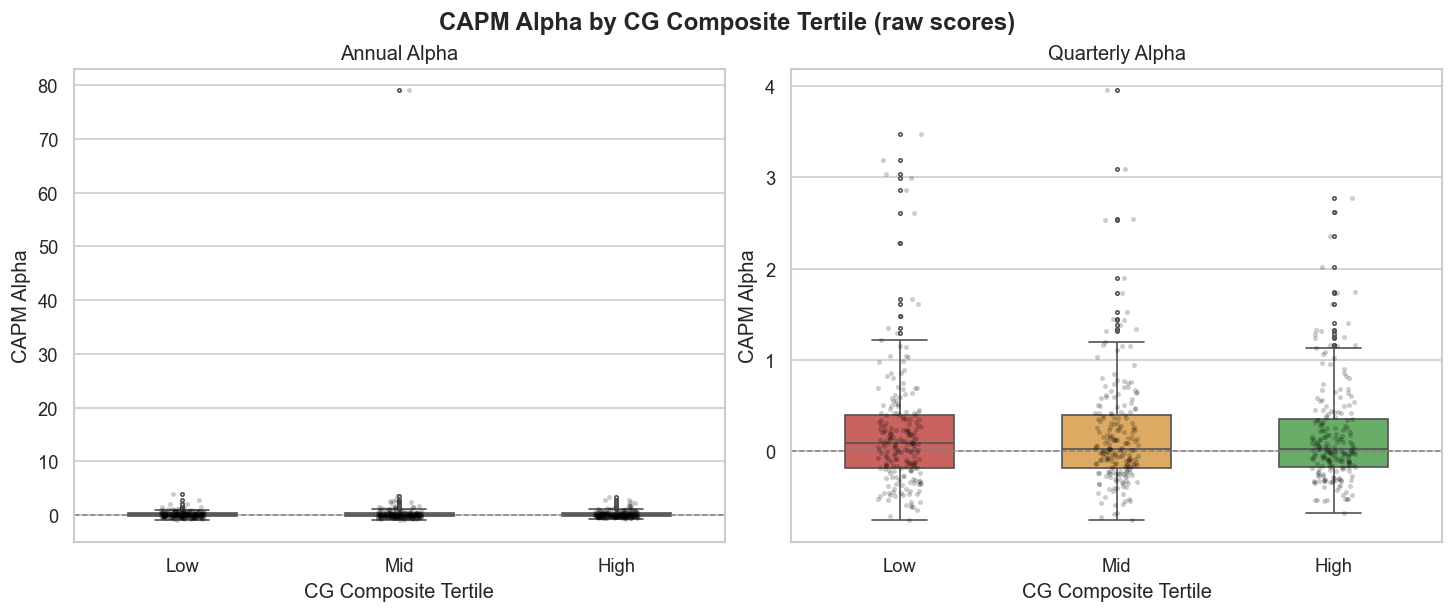

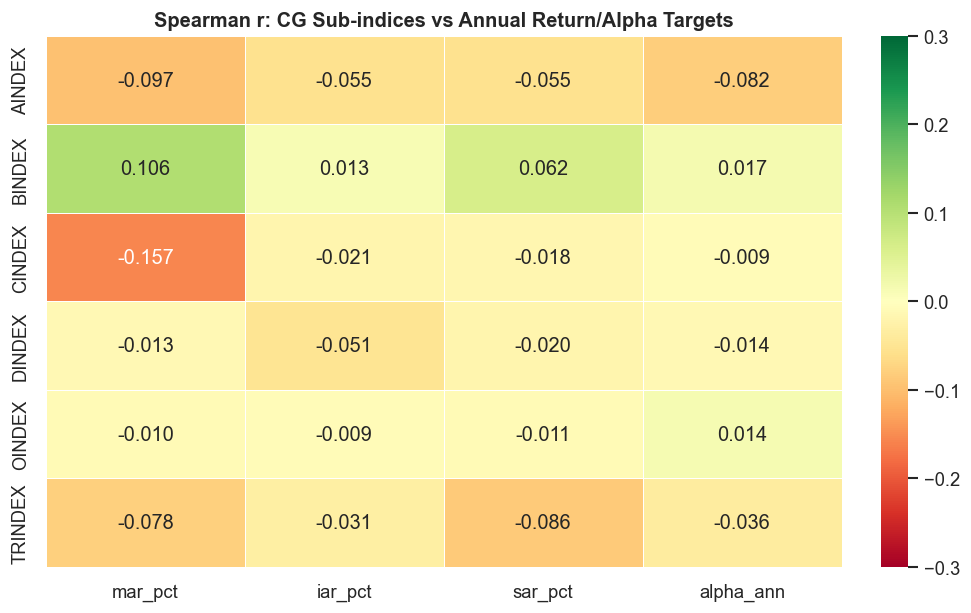

In [6]:
# Section 1: Tertile EDA — Raw CG Composite vs Alpha

def trim_corr_predictor_outliers(df, predictor_cols, z_thresh=2.0):
    X = df[predictor_cols].astype(float)
    sigma = X.std().replace(0, np.nan)
    z = X.sub(X.mean()).div(sigma)
    keep = z.abs().le(z_thresh).fillna(True).all(axis=1)
    return df.loc[keep].copy(), int((~keep).sum())

def tertile_table(df, y_col, cg_col, period_label):
    sub = df[[y_col, cg_col]].dropna().copy()
    sub, removed = trim_corr_predictor_outliers(sub, [cg_col], z_thresh=2.0)
    sub['tertile'] = pd.qcut(sub[cg_col], 3, labels=['Low','Mid','High'])
    tbl = sub.groupby('tertile')[y_col].agg(['mean','median','count'])
    tbl.columns = ['Mean','Median','N']
    r_p, p_p = stats.pearsonr(*sub[[cg_col, y_col]].dropna().values.T)
    r_s, p_s = stats.spearmanr(*sub[[cg_col, y_col]].dropna().values.T)
    print(f'\n--- {period_label}: {y_col} by CG Composite Tertile ---')
    if removed:
        print(f'  Removed {removed} rows with {cg_col} outside ±2 SD')
    print(tbl.round(4).to_string())
    print(f'  Pearson  r = {r_p:+.4f}  p = {p_p:.4f} {sig_stars(p_p)}')
    print(f'  Spearman r = {r_s:+.4f}  p = {p_s:.4f} {sig_stars(p_s)}')
    return sub

# Annual alpha tertile analysis
ann_eda = (a_alpha[['BSE Code','FY','capm_alpha_annual']]
           .merge(cg_ann_raw[['BSE Code','FY','COMPOSITE']], on=['BSE Code','FY'], how='inner'))
sub_ann = tertile_table(ann_eda, 'capm_alpha_annual', 'COMPOSITE', 'Annual')

# Quarterly alpha tertile analysis
qtr_eda = (q_alpha[['BSE Code','Q_FY','capm_alpha_quarterly']]
           .merge(cg_q_raw[['BSE Code','Q_FY','COMPOSITE']], on=['BSE Code','Q_FY'], how='inner'))
sub_qtr = tertile_table(qtr_eda, 'capm_alpha_quarterly', 'COMPOSITE', 'Quarterly')

# Pearson/Spearman correlation table: all CG indices vs all annual Y vars
print('\n\n=== Correlation Table: CG Sub-indices vs Annual Returns & Alpha ===')
y_targets_ann = {
    'mar_pct'   : a_ret[['BSE Code','FY','mar_pct']],
    'iar_pct'   : a_ret[['BSE Code','FY','iar_pct']],
    'sar_pct'   : a_ret[['BSE Code','FY','sar_pct']],
    'alpha_ann' : a_alpha[['BSE Code','FY','capm_alpha_annual']].rename(columns={'capm_alpha_annual':'alpha_ann'}),
}
corr_rows = []
for y_name, y_df in y_targets_ann.items():
    for cg_cat in ALL_CATS:
        if cg_cat not in cg_ann_raw.columns:
            continue
        merged = y_df.merge(cg_ann_raw[['BSE Code','FY',cg_cat]], on=['BSE Code','FY'], how='inner').dropna().copy()
        merged, removed = trim_corr_predictor_outliers(merged, [cg_cat], z_thresh=2.0)
        yv  = merged.iloc[:,2].values
        cgv = merged[cg_cat].values
        if len(yv) < 10:
            continue
        r_p, p_p = stats.pearsonr(cgv, yv)
        r_s, p_s = stats.spearmanr(cgv, yv)
        corr_rows.append({'Y': y_name, 'CG': cg_cat,
                          'Pearson_r': r_p, 'Pearson_p': p_p, 'Pearson_sig': sig_stars(p_p),
                          'Spearman_r': r_s, 'Spearman_p': p_s, 'Spearman_sig': sig_stars(p_s),
                          'N': len(yv), 'Removed': removed})
corr_df = pd.DataFrame(corr_rows)
print(corr_df[['Y','CG','Pearson_r','Pearson_sig','Spearman_r','Spearman_sig','N','Removed']]
      .to_string(index=False, float_format='{:.4f}'.format))

# Visualisation: box plots (annual alpha by CG composite tertile)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('CAPM Alpha by CG Composite Tertile (raw scores)', fontweight='bold')
for ax, (sub, title_) in zip(axes, [(sub_ann, 'Annual Alpha'), (sub_qtr, 'Quarterly Alpha')]):
    y_col = 'capm_alpha_annual' if 'capm_alpha_annual' in sub.columns else 'capm_alpha_quarterly'
    order = ['Low','Mid','High']
    pal   = {'Low':'#d9534f','Mid':'#f0ad4e','High':'#5cb85c'}
    sns.boxplot(data=sub, x='tertile', y=y_col, order=order, palette=pal, width=0.5, ax=ax,
                flierprops={'marker':'.','markersize':4})
    sns.stripplot(data=sub, x='tertile', y=y_col, order=order, alpha=0.2,
                  color='black', size=3, jitter=True, ax=ax)
    ax.axhline(0, ls='--', color='grey', lw=0.9)
    ax.set_title(title_)
    ax.set_xlabel('CG Composite Tertile')
    ax.set_ylabel('CAPM Alpha')
plt.show()

# Heatmap: Spearman r (annual)
heat_data = (corr_df.pivot(index = 'CG', columns = 'Y', values = 'Spearman_r')
             .reindex(index = ALL_CATS, columns = list(y_targets_ann.keys())))
fig, ax = plt.subplots(figsize = (8, 5), constrained_layout = True)
sns.heatmap(heat_data.astype(float), annot = True, fmt = '.3f', cmap = 'RdYlGn',
            center = 0, linewidths = 0.4, ax = ax, vmin = -0.3, vmax = 0.3)
ax.set_title('Spearman r: CG Sub-indices vs Annual Return/Alpha Targets', fontweight = 'bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.show()

---
## Section 2 — Annual Returns: MAR · IAR · SAR · Alpha

Y = cumulative return metric over the **252 trading-day window starting from the earliest CG filing date** within each FY.  
X = Van der Waerden-normalised CG sub-index (cross-section within FY).  
Controls: Beta\_Market, Momentum, Log\_MarketCap, DE\_Ratio (annual average of quarterly values).  
FY fixed effects (FY24, FY25 dummies) · Firm-clustered SE.


  Annual Returns ~ Individual CG Index (VdW) + Controls + FY FE
CG Index          mar_pct             iar_pct             sar_pct            capm_alpha     
                   β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------
AINDEX        -0.0005 (0.0118)    +0.0012 (0.0121)    +0.0072 (0.0135)    -0.0203 (0.0205)  
BINDEX       +0.0248** (0.0121)   +0.0015 (0.0132)    +0.0239 (0.0147)    -0.0162 (0.0239)  
CINDEX        +0.0054 (0.0139)    +0.0059 (0.0141)    +0.0086 (0.0158)   +0.0488** (0.0216) 
DINDEX        +0.0071 (0.0124)    -0.0072 (0.0131)    +0.0097 (0.0153)    -0.0009 (0.0233)  
OINDEX        -0.0070 (0.0112)    +0.0025 (0.0113)    -0.0086 (0.0142)   +0.0427** (0.0215) 
TRINDEX      -0.0242** (0.0116)   -0.0090 (0.0120)   -0.0303** (0.0140)   +0.0067 (0.0257)  
----------------------------------------------------------------------------------------------
C

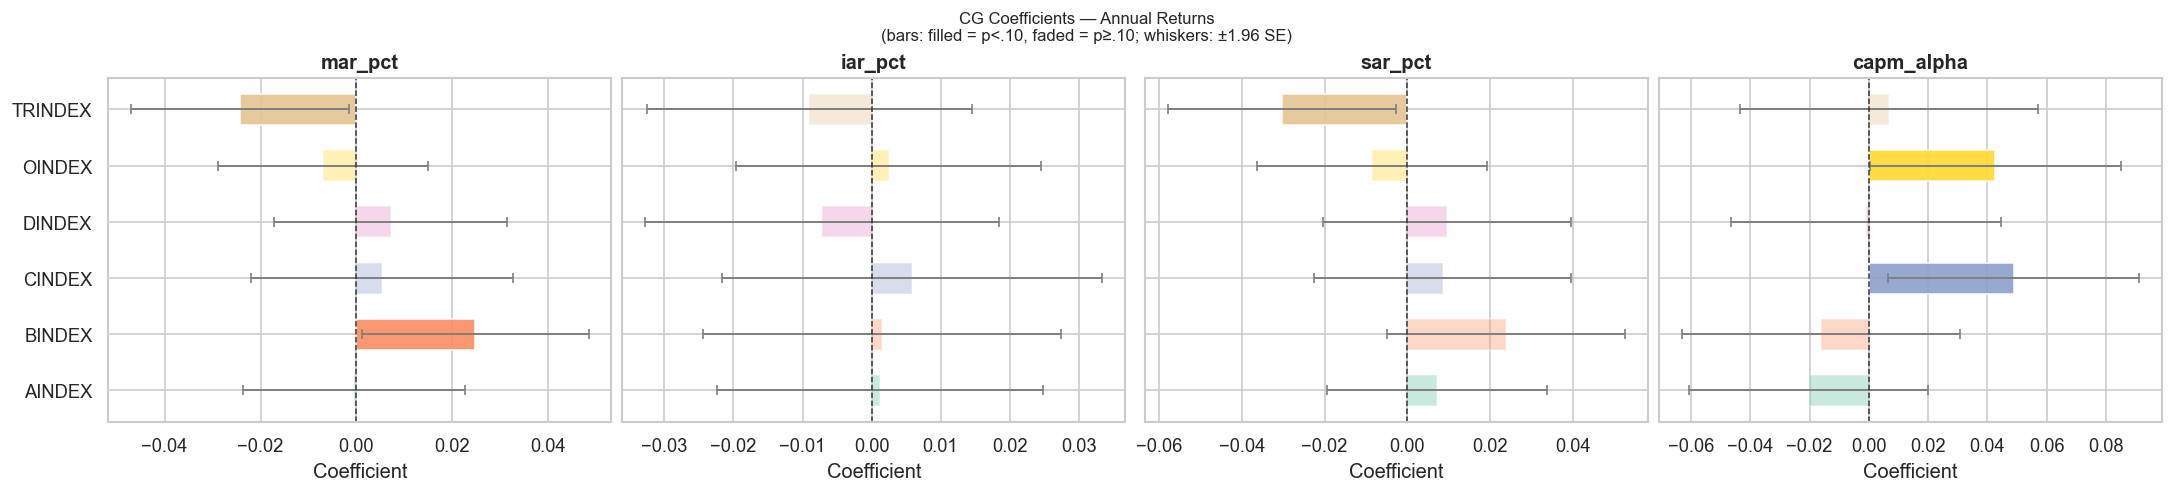

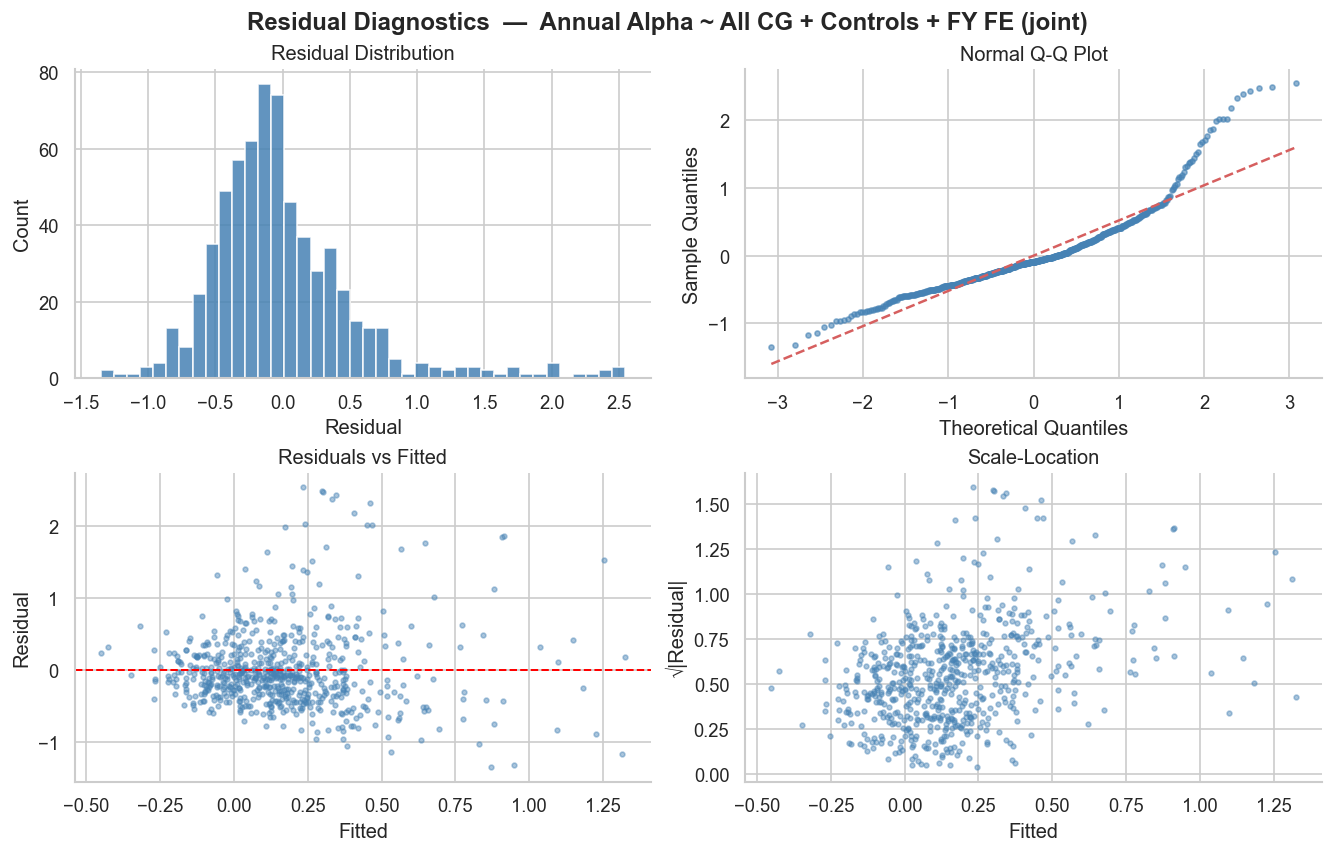

  JB p=0.0000 ('normal' if p>.05)  |  BP p=0.0000 ('homoskedastic' if p>.05, clustered SE corrects for this)  |  DW=1.894


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 2: Annual Returns Regressions
# ══════════════════════════════════════════════════════════════════════════════

# Merge all annual return targets + CG VdW + controls
_ann_targets = {
    'mar_pct'   : a_ret[['BSE Code','NSE Symbol','FY','mar_pct']],
    'iar_pct'   : a_ret[['BSE Code','NSE Symbol','FY','iar_pct']],
    'sar_pct'   : a_ret[['BSE Code','NSE Symbol','FY','sar_pct']],
    'capm_alpha': a_alpha[['BSE Code','NSE Symbol','FY','capm_alpha_annual']]
                         .rename(columns={'capm_alpha_annual':'capm_alpha'}),
}
ANN_Y   = list(_ann_targets.keys())
CG_AVAIL = [c for c in ALL_CATS if c in cg_ann_vdw.columns]

def make_ann_model_df(y_col, y_df):
    fe = fe_dummies(cg_ann_vdw, 'FY', 'FY') if 'FY' in cg_ann_vdw.columns else pd.DataFrame()
    df = (y_df[['BSE Code','NSE Symbol','FY',y_col]]
          .merge(cg_ann_vdw[['BSE Code','FY'] + CG_AVAIL], on=['BSE Code','FY'], how='inner')
          .merge(ctrl_a[['BSE Code','FY'] + CTRL], on=['BSE Code','FY'], how='left'))
    if not fe.empty:
        df = pd.concat([df, fe_dummies(df, 'FY', 'FY')], axis=1)
    return df

ann_model_dfs = {y: make_ann_model_df(y, df) for y, df in _ann_targets.items()}

# ── Individual models: one CG index at a time ─────────────────────────────────
ann_run = {}   # {(y_col, cg_label): (res, diag)}
for y_col in ANN_Y:
    df = ann_model_dfs[y_col]
    fe_cols = [c for c in df.columns if c.startswith('_FE_')]
    for cg in CG_AVAIL:
        x_cols = [cg] + CTRL + fe_cols
        res, diag = run_ols(df, y_col, x_cols)
        ann_run[(y_col, cg)] = (res, diag)

print_reg_table(ann_run, ANN_Y, CG_AVAIL, title='Annual Returns ~ Individual CG Index (VdW) + Controls + FY FE')

# ── Joint model: all CG indices simultaneously ────────────────────────────────
print('\n--- Joint Model (all sub-indices together) ---')
ann_joint = {}  # {y_col: (res, diag)}
for y_col in ANN_Y:
    df = ann_model_dfs[y_col]
    fe_cols = [c for c in df.columns if c.startswith('_FE_')]
    x_cols  = CG_CATS + CTRL + fe_cols   # exclude COMPOSITE
    x_cols  = [c for c in x_cols if c in df.columns]
    res, diag = run_ols(df, y_col, x_cols)
    ann_joint[y_col] = (res, diag)

print_joint_table(ann_joint, ANN_Y, [c for c in CG_CATS if c in cg_ann_vdw.columns],
                  title='Annual Returns ~ All CG Indices (Joint)')

# ── VIF for joint model ────────────────────────────────────────────────────────
_, jd = ann_joint.get(ANN_Y[0], (None, None))
if jd is not None and not jd['VIF'].empty:
    print('\nVIF — Joint Model (Annual Returns, MAR):')
    print(jd['VIF'].to_string(index=False))

# ── Coefficient forest plot ────────────────────────────────────────────────────
plot_coef_forest(ann_run, ANN_Y, CG_AVAIL, 'Annual Returns')

# ── Diagnostics for joint model on CAPM Alpha ─────────────────────────────────
_, diag_ann = ann_joint.get('capm_alpha', (None, None))
if diag_ann:
    plot_diagnostics(diag_ann, 'Annual Alpha ~ All CG + Controls + FY FE (joint)')

---
## Section 3 — Quarterly Returns: MAR · IAR · SAR · Alpha

Y = cumulative return metric over the **63 trading-day window starting from the Q\_FY CG filing date**.  
X = Van der Waerden-normalised **weighted-average CG** across last 4 quarters (weights 4-3-2-1, most recent = 4).  
Controls: quarterly Beta\_Market, Momentum, Log\_MarketCap, DE\_Ratio.  
Quarter-FY fixed effects · Firm-clustered SE.


  Quarterly Returns ~ Individual CG Index (VdW 4-3-2-1 weighted) + Controls + Q-FY FE
CG Index          mar_pct             iar_pct             sar_pct            capm_alpha     
                   β (SE)              β (SE)              β (SE)              β (SE)       
----------------------------------------------------------------------------------------------
AINDEX       +0.0123* (0.0072)    +0.0081 (0.0055)    +0.0114 (0.0070)    -0.0227 (0.0234)  
BINDEX        -0.0046 (0.0087)    -0.0053 (0.0071)    -0.0137 (0.0086)  +0.0747*** (0.0252) 
CINDEX        -0.0083 (0.0094)    -0.0083 (0.0072)    -0.0066 (0.0090)    -0.0172 (0.0298)  
DINDEX        +0.0052 (0.0086)    -0.0011 (0.0069)    +0.0025 (0.0081)    +0.0281 (0.0271)  
OINDEX        -0.0104 (0.0086)    -0.0042 (0.0063)    -0.0072 (0.0085)    -0.0070 (0.0219)  
TRINDEX       -0.0076 (0.0080)    -0.0062 (0.0064)    -0.0048 (0.0079)    +0.0018 (0.0258)  
--------------------------------------------------------------------------

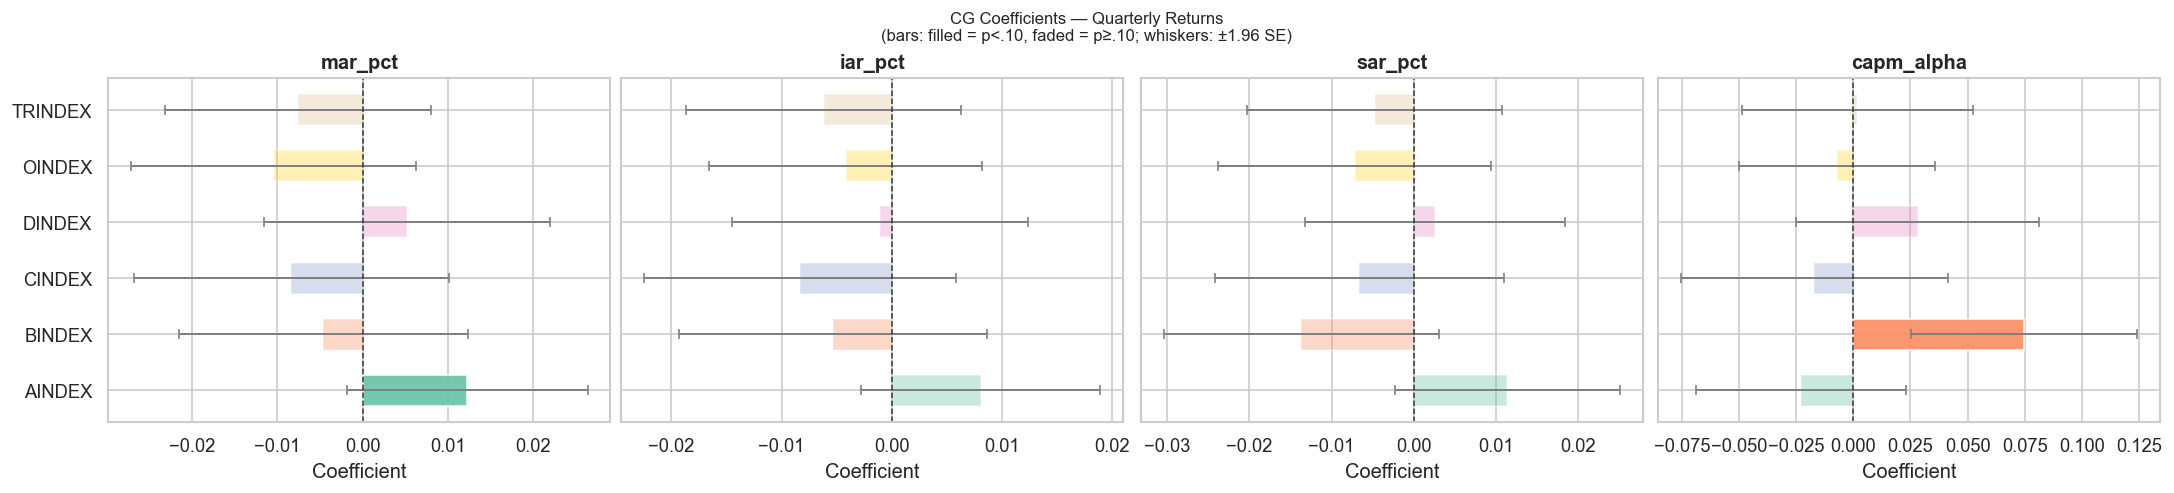

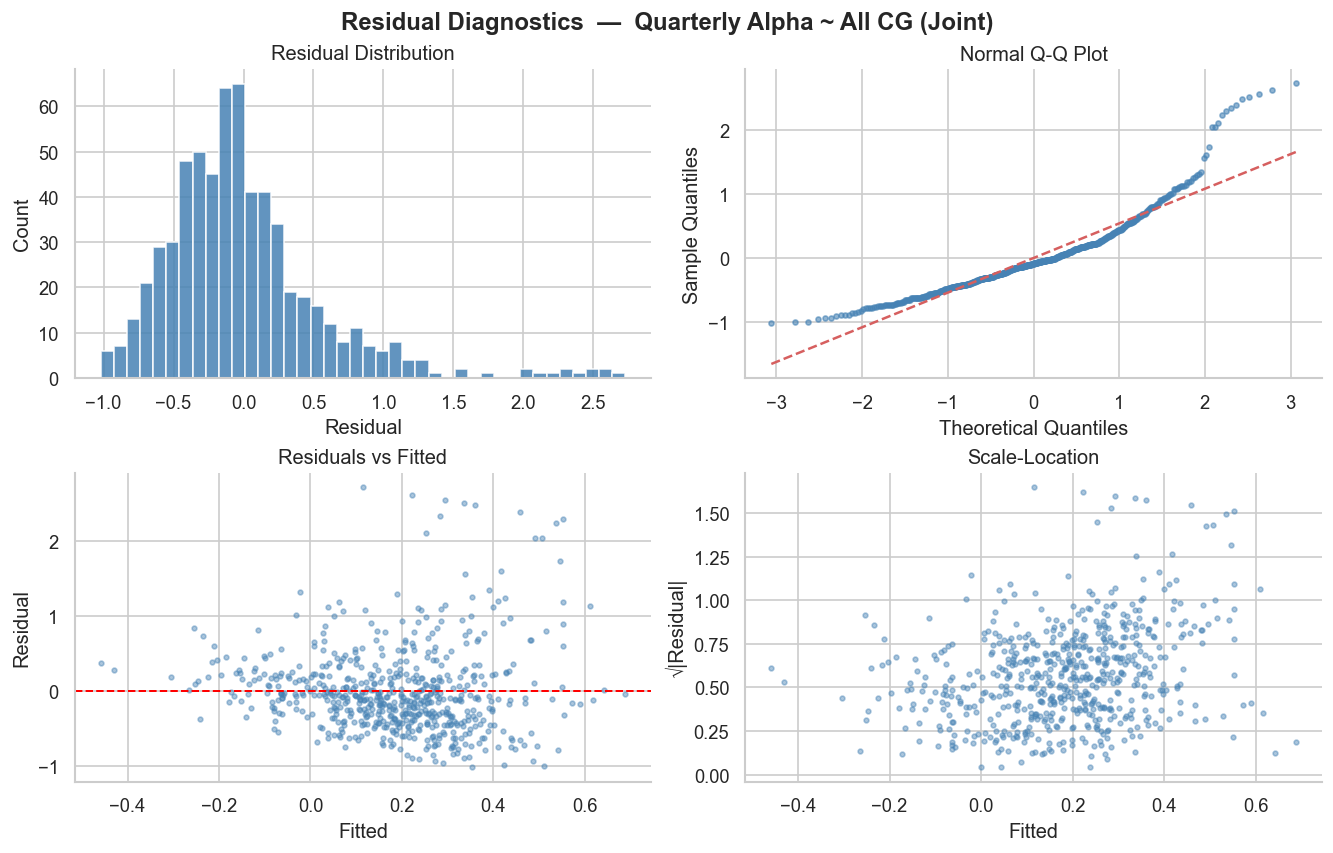

  JB p=0.0000 ('normal' if p>.05)  |  BP p=0.0000 ('homoskedastic' if p>.05, clustered SE corrects for this)  |  DW=1.957


In [8]:
# Section 3: Quarterly Returns Regressions

_qtr_targets = {
    'mar_pct'   : q_ret[['BSE Code','NSE Symbol','Q_FY','mar_pct']],
    'iar_pct'   : q_ret[['BSE Code','NSE Symbol','Q_FY','iar_pct']],
    'sar_pct'   : q_ret[['BSE Code','NSE Symbol','Q_FY','sar_pct']],
    'capm_alpha': q_alpha[['BSE Code','NSE Symbol','Q_FY','capm_alpha_quarterly']]
                         .rename(columns={'capm_alpha_quarterly':'capm_alpha'}),
}
QTR_Y    = list(_qtr_targets.keys())
CG_Q_AVAIL = [c for c in ALL_CATS if c in cg_q_vdw.columns]

def make_qtr_model_df(y_col, y_df):
    df = (y_df[['BSE Code','NSE Symbol','Q_FY',y_col]]
          .merge(cg_q_vdw[['BSE Code','Q_FY'] + CG_Q_AVAIL], on=['BSE Code','Q_FY'], how='inner')
          .merge(ctrl_q[['BSE Code','Q_FY'] + CTRL], on=['BSE Code','Q_FY'], how='left'))
    df = pd.concat([df, fe_dummies(df, 'Q_FY', 'Q')], axis=1)
    return df

qtr_model_dfs = {y: make_qtr_model_df(y, df) for y, df in _qtr_targets.items()}

# Individual models
qtr_run = {}
for y_col in QTR_Y:
    df = qtr_model_dfs[y_col]
    fe_cols = [c for c in df.columns if c.startswith('_FE_')]
    for cg in CG_Q_AVAIL:
        x_cols = [cg] + CTRL + fe_cols
        res, diag = run_ols(df, y_col, x_cols)
        qtr_run[(y_col, cg)] = (res, diag)

print_reg_table(qtr_run, QTR_Y, CG_Q_AVAIL,
                title='Quarterly Returns ~ Individual CG Index (VdW 4-3-2-1 weighted) + Controls + Q-FY FE')

# Joint model
print('\n--- Joint Model ---')
qtr_joint = {}
for y_col in QTR_Y:
    df = qtr_model_dfs[y_col]
    fe_cols = [c for c in df.columns if c.startswith('_FE_')]
    x_cols  = [c for c in CG_CATS if c in df.columns] + CTRL + fe_cols
    res, diag = run_ols(df, y_col, x_cols)
    qtr_joint[y_col] = (res, diag)

print_joint_table(qtr_joint, QTR_Y, [c for c in CG_CATS if c in cg_q_vdw.columns],
                  title='Quarterly Returns ~ All CG Indices (Joint)')

# VIF
_, jd = qtr_joint.get(QTR_Y[0], (None, None))
if jd is not None and not jd['VIF'].empty:
    print('\nVIF — Joint Model (Quarterly, MAR):')
    print(jd['VIF'].to_string(index=False))

plot_coef_forest(qtr_run, QTR_Y, CG_Q_AVAIL, 'Quarterly Returns')

_, diag_qtr = qtr_joint.get('capm_alpha', (None, None))
if diag_qtr:
    plot_diagnostics(diag_qtr, 'Quarterly Alpha ~ All CG (Joint)')

---
## Section 4 — Annual Volatility

Y-variable set: **filing-date window** (`annual_vol_from_filing`), a 252 td window starting from the earliest CG filing date in the FY.

Three volatility measures: `total_vol` (excess return std), `idio_vol` (CAPM residual std), `downside_vol` (negative-residual std).  
X = Van der Waerden-normalised CG sub-indices (annual).  
Controls + FY FE + firm-clustered SE.

=== Filing-date volatility window ===

  Annual Vol (filing window) ~ Individual CG + Controls + FY FE
CG Index         total_vol          downside_vol    
                   β (SE)              β (SE)       
------------------------------------------------------
AINDEX        -0.0004 (0.0002)    -0.0001 (0.0001)  
BINDEX        +0.0003 (0.0003)    +0.0003 (0.0002)  
CINDEX        -0.0002 (0.0002)    -0.0001 (0.0001)  
DINDEX        +0.0002 (0.0002)    -0.0000 (0.0002)  
OINDEX        -0.0004 (0.0003)    -0.0002 (0.0002)  
TRINDEX     -0.0007*** (0.0002)   -0.0001 (0.0002)  
------------------------------------------------------
Controls            Yes                 Yes         
FY/Q FE             Yes                 Yes         
N                    —                   —          
R²                   —                   —          
* p<.10  ** p<.05  *** p<.01  | firm-clustered SE | Y winsorised 1%-99%

  Annual Vol (filing window) ~ All CG (Joint)  (joint model)
Variable         

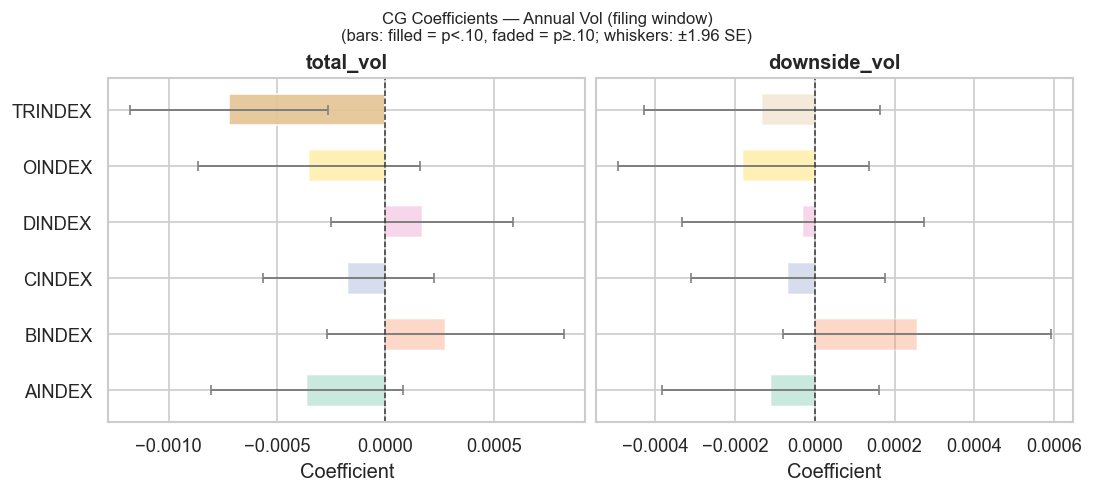

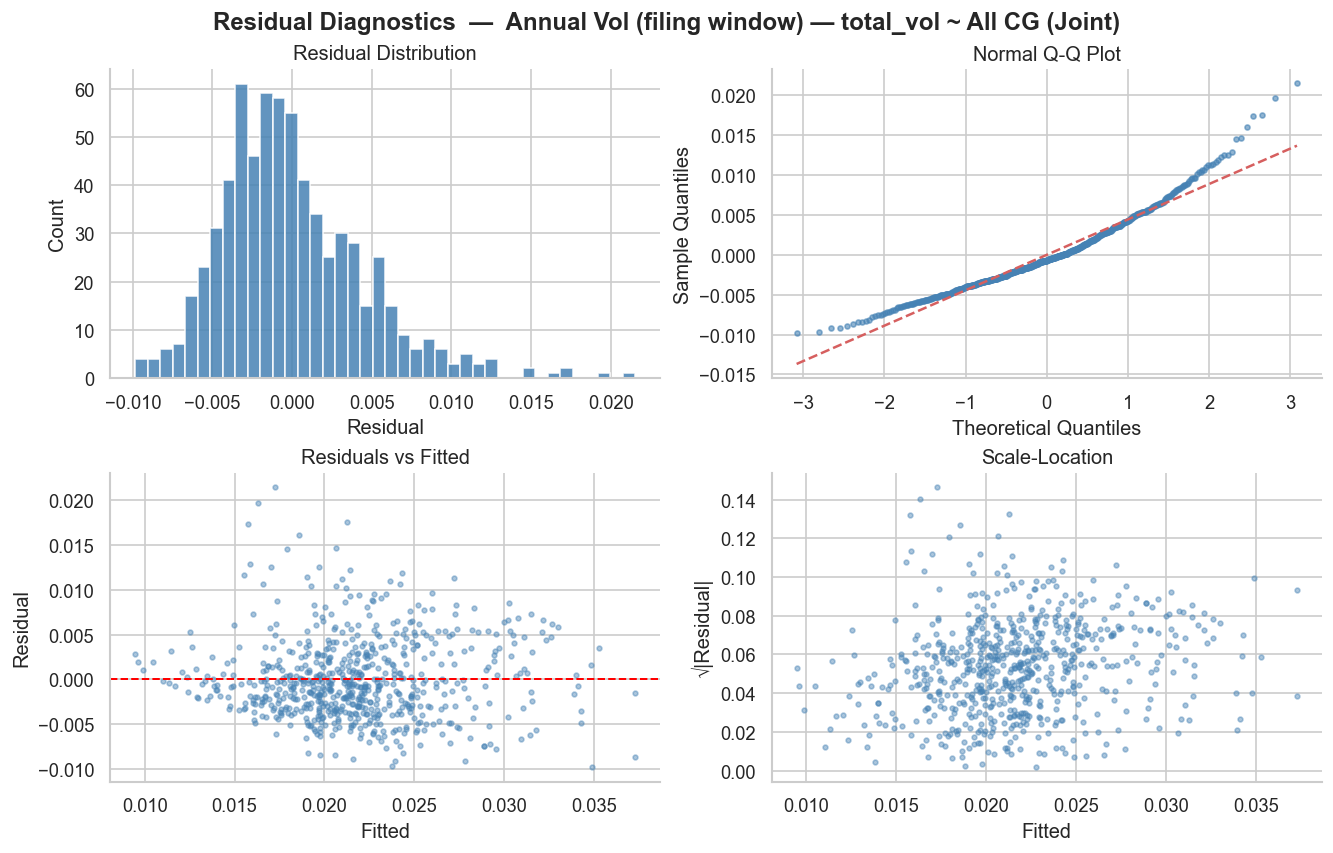

  JB p=0.0000 ('normal' if p>.05)  |  BP p=0.0052 ('homoskedastic' if p>.05, clustered SE corrects for this)  |  DW=1.962


In [9]:
# Section 4: Annual Volatility Regressions

VOL_Y = ['total_vol', 'idio_vol', 'downside_vol']

def run_vol_section(vol_df, label):
    vol_df = vol_df.copy()
    vol_df = bse_int(vol_df)
    if 'FY_CG' in vol_df.columns:
        vol_df['FY'] = vol_df['FY_CG']
    vol_targets = {y: vol_df[['BSE Code','NSE Symbol','FY', y]] for y in VOL_Y
                   if y in vol_df.columns}
    if not vol_targets:
        print(f'{label}: no vol columns found'); return {}, {}

    run_d = {}   # {(y, cg): (res, diag)}
    joint = {}   # {y: (res, diag)}

    for y_col, y_df in vol_targets.items():
        df = (y_df.merge(cg_ann_vdw[['BSE Code','FY'] + CG_AVAIL], on=['BSE Code','FY'], how='inner')
                  .merge(ctrl_a[['BSE Code','FY'] + CTRL], on=['BSE Code','FY'], how='left'))
        df = pd.concat([df, fe_dummies(df,'FY','FY')], axis=1)
        fe_cols = [c for c in df.columns if c.startswith('_FE_')]
        for cg in CG_AVAIL:
            res, diag = run_ols(df, y_col, [cg] + CTRL + fe_cols)
            run_d[(y_col, cg)] = (res, diag)
        jx = [c for c in CG_CATS if c in df.columns] + CTRL + fe_cols
        res, diag = run_ols(df, y_col, jx)
        joint[y_col] = (res, diag)

    print_reg_table(run_d, list(vol_targets.keys()), CG_AVAIL,
                    title=f'{label} ~ Individual CG + Controls + FY FE')
    print_joint_table(joint, list(vol_targets.keys()),
                      [c for c in CG_CATS if c in cg_ann_vdw.columns],
                      title=f'{label} ~ All CG (Joint)')
    _, jd = next(iter(joint.values())) if joint else (None, None)
    if jd and not jd['VIF'].empty:
        print(f'\nVIF ({label}, total_vol):')
        print(jd['VIF'].to_string(index=False))
    plot_coef_forest(run_d, list(vol_targets.keys()), CG_AVAIL, label)
    y0 = list(vol_targets.keys())[0]
    _, diag0 = joint.get(y0, (None, None))
    if diag0:
        plot_diagnostics(diag0, f'{label} — {y0} ~ All CG (Joint)')
    return run_d, joint

print('=== Filing-date volatility window ===')
avf_run, avf_joint = run_vol_section(a_vol_f, 'Annual Vol (filing window)')

---
## Section 5 — Return on Equity (ROE)

Y = `roe` (Net Income / |Stockholders Equity|) for the Indian FY (Apr–Mar).  
X = Van der Waerden-normalised CG sub-indices (annual).  
Controls: Beta\_Market, Momentum, Log\_MarketCap, DE\_Ratio.  
Note: DE\_Ratio is retained as it captures capital structure effects beyond the ROE denominator.  
FY fixed effects · Firm-clustered SE.


  ROE ~ Individual CG Index (VdW) + Controls + FY FE
CG Index            roe         
                   β (SE)       
----------------------------------
AINDEX        -0.0183 (0.0124)  
BINDEX       +0.0167* (0.0089)  
CINDEX        -0.0092 (0.0056)  
DINDEX        -0.0198 (0.0144)  
OINDEX        +0.0120 (0.0130)  
TRINDEX     +0.0209*** (0.0079) 
----------------------------------
Controls            Yes         
FY/Q FE             Yes         
N                    —          
R²                   —          
* p<.10  ** p<.05  *** p<.01  | firm-clustered SE | Y winsorised 1%-99%

  ROE ~ All CG Indices (Joint)  (joint model)
Variable            roe         
----------------------------------
AINDEX        -0.0188 (0.0122)  
BINDEX       +0.0179** (0.0082) 
CINDEX        -0.0075 (0.0059)  
DINDEX        -0.0178 (0.0135)  
OINDEX        +0.0130 (0.0121)  
TRINDEX     +0.0233*** (0.0086) 
const        -0.6954** (0.2821) 
Beta_Market -0.1141*** (0.0229) 
Momentum    +0.0532*** (0.010

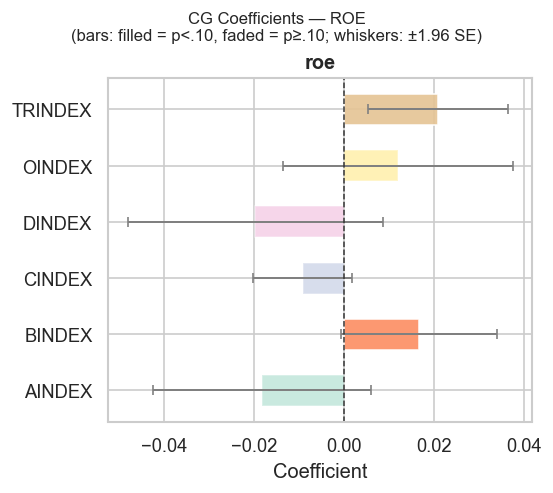

In [10]:
# Section 6: ROE Regressions

roe_df = a_roe.copy()
roe_df = bse_int(roe_df)

# Trim extreme ROE (mechanical outliers from near-zero equity)
roe_df = roe_df[roe_df['roe'].between(-2, 5)].copy()

roe_merged = (roe_df[['BSE Code','NSE Symbol','FY','roe']]
              .merge(cg_ann_vdw[['BSE Code','FY'] + CG_AVAIL], on=['BSE Code','FY'], how='inner')
              .merge(ctrl_a[['BSE Code','FY'] + CTRL], on=['BSE Code','FY'], how='left'))
roe_merged = pd.concat([roe_merged, fe_dummies(roe_merged,'FY','FY')], axis=1)
fe_cols = [c for c in roe_merged.columns if c.startswith('_FE_')]

# Individual models
roe_run = {}
for cg in CG_AVAIL:
    res, diag = run_ols(roe_merged, 'roe', [cg] + CTRL + fe_cols, winsor=False)  # already trimmed
    roe_run[('roe', cg)] = (res, diag)

print_reg_table(roe_run, ['roe'], CG_AVAIL, title='ROE ~ Individual CG Index (VdW) + Controls + FY FE')

# Joint model
jx = [c for c in CG_CATS if c in roe_merged.columns] + CTRL + fe_cols
roe_joint_res, roe_joint_diag = run_ols(roe_merged, 'roe', jx, winsor=False)
roe_joint = {'roe': (roe_joint_res, roe_joint_diag)}

print_joint_table(roe_joint, ['roe'],
                  [c for c in CG_CATS if c in cg_ann_vdw.columns],
                  title='ROE ~ All CG Indices (Joint)')

if roe_joint_diag and not roe_joint_diag['VIF'].empty:
    print('\nVIF — ROE Joint Model:')
    print(roe_joint_diag['VIF'].to_string(index=False))

plot_coef_forest(roe_run, ['roe'], CG_AVAIL, 'ROE')